In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('/content/2016_Building_Energy_Benchmarking.csv')
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [ ]:
df.shape

(3376, 46)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [ ]:
# Statistiques descriptives
df.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,...,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,...,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,...,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,...,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,...,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,...,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,...,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


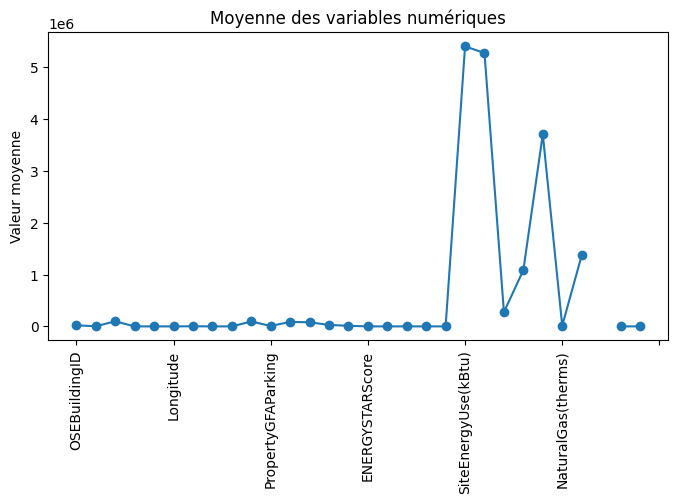

In [ ]:
desc = df.describe()

means = desc.loc['mean']

plt.figure(figsize=(8,4))
means.plot(marker='o')
plt.xticks(rotation=90)
plt.title("Moyenne des variables numériques")
plt.ylabel("Valeur moyenne")
plt.show()

In [ ]:
df.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [ ]:
# à supprimer
df = df.drop(columns=['Comments', 'Electricity(kWh)', 'GHGEmissionsIntensity', 'YearsENERGYSTARCertified',
                      'ThirdLargestPropertyUseType', 'SecondLargestPropertyUseType', 'CouncilDistrictCode',
                      'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
                      'ThirdLargestPropertyUseTypeGFA', 'OSEBuildingID', 'TaxParcelIdentificationNumber', 'ComplianceStatus',
                      'Outlier', 'ListOfAllPropertyUseTypes', 'ListOfAllPropertyUseTypes', 'DefaultData', 'Address', 'City',
                      'State', 'ZipCode', 'SteamUse(kBtu)', 'NaturalGas(therms)'
                      ])

In [ ]:
df

,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,...,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions
0,2016,NonResidential,Hotel,Mayflower park hotel,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,...,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,3.946027e+06,1.276453e+06,249.98
1,2016,NonResidential,Hotel,Paramount Hotel,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,...,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,3.242851e+06,5.145082e+06,295.86
2,2016,NonResidential,Hotel,5673-The Westin Seattle,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,...,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,4.952666e+07,1.493800e+06,2089.28
3,2016,NonResidential,Hotel,HOTEL MAX,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,...,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2.768924e+06,1.811213e+06,286.43
4,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),DOWNTOWN,47.61375,-122.34047,1980,1.0,18,...,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,5.368607e+06,8.803998e+06,505.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,2016,Nonresidential COS,Office,Horticulture building,GREATER DUWAMISH,47.56722,-122.31154,1990,1.0,1,...,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,5.242709e+05,3.254750e+05,20.94
3372,2016,Nonresidential COS,Other,International district/Chinatown CC,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,...,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,3.965461e+05,5.537300e+05,32.17
3373,2016,Nonresidential COS,Other,Queen Anne Pool,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1.0,1,...,NaN,438.200012,460.100006,744.799988,767.799988,5.765898e+06,6.053764e+06,1.792159e+06,3.973739e+06,223.54
3374,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,GREATER DUWAMISH,47.52832,-122.32431,1989,1.0,1,...,NaN,51.000000,55.500000,105.300003,110.800003,7.194712e+05,7.828413e+05,3.488702e+05,3.706010e+05,22.11


In [ ]:
df.isna().sum()

,0
DataYear,0
BuildingType,0
PrimaryPropertyType,0
PropertyName,0
Neighborhood,0
Latitude,0
Longitude,0
YearBuilt,0
NumberofBuildings,8
NumberofFloors,0


In [ ]:
# Nettoyage de la donnée cible
df.dropna(subset=['SiteEnergyUse(kBtu)'], inplace=True)
df = df[df['SiteEnergyUse(kBtu)'] > 0]

Text(0.5, 1.0, "Distribution de l'Énergie (SiteEnergyUse(kBtu))")

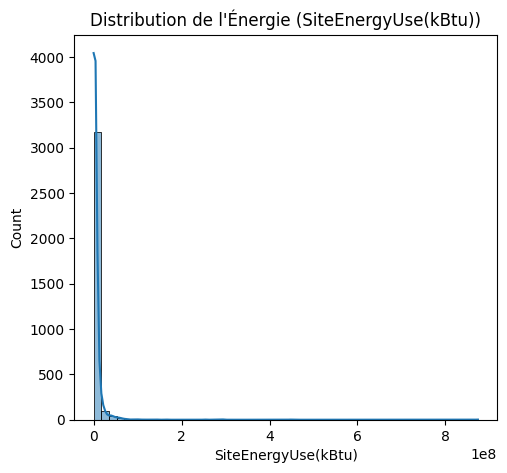

In [ ]:
# Affichage de la distribution de l'énergie (fortement asymétrique)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.histplot(df['SiteEnergyUse(kBtu)'], bins=50, kde=True)
plt.title("Distribution de l'Énergie (SiteEnergyUse(kBtu))")

In [ ]:
# Transformation logarithmique de la cible
df = df[df["DataYear"] == 2016].copy()
df['SiteEnergyUse_Log'] = np.log1p(df['SiteEnergyUse(kBtu)'])


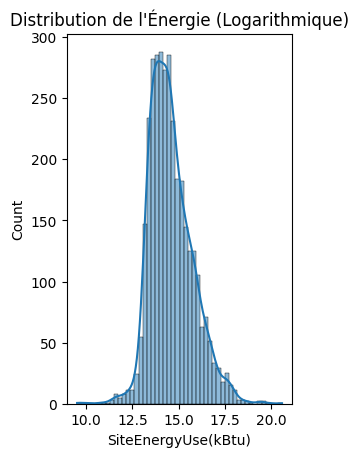

In [ ]:
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['SiteEnergyUse(kBtu)']), bins=50, kde=True)
plt.title("Distribution de l'Énergie (Logarithmique)")
plt.show()

In [ ]:
# Sélection des caractéristiques & Prétraitement
# Exclusion des variables qui sont des dérivés directs de la cible pour éviter les fuites de données
features = [
    'BuildingType', 'PrimaryPropertyType', 'YearBuilt', 'NumberofFloors',
    'PropertyGFATotal', 'Latitude', 'Longitude'
]
features_energystar = features + ['ENERGYSTARScore']

categorical_features = ['BuildingType', 'PrimaryPropertyType']
numerical_features_base = [col for col in features if col not in categorical_features]
numerical_features_energystar = [col for col in features_energystar if col not in categorical_features]


In [ ]:
# Pipelines de prétraitement
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features_base),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

In [ ]:
preprocessor_energystar = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features_energystar),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

In [ ]:
# Entraînement et Évaluation des modèles
def train_and_evaluate(features, preprocessor, target):
    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
models = {
        "Régression Linéaire": LinearRegression(),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Réseau de Neurones (MLP)": MLPRegressor(random_state=42, max_iter=500, early_stopping=True)
    }

In [ ]:
for name, model in models.items():
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])

In [ ]:
X = df[features]
y = df['SiteEnergyUse_Log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [ ]:
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['YearBuilt',
                                                   'NumberofFloors',
                                                   'PropertyGFATotal',
                                                   'Latitude', 'Longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BuildingType',
                                                   'PrimaryPropertyType'])])),
                ('regressor',
                 MLPRegressor(early_stopping=True, max_iter=500,
                              random_state=42))])

In [ ]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.5408701486491343
RMSE: 0.7908188449611901


In [ ]:
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])
pipeline_rf.fit(X_train, y_train)
y_pred = pipeline_rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.7232330297025826
RMSE: 0.6139971772318962


In [ ]:
pipeline_gb = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(random_state=42))])
pipeline_gb.fit(X_train, y_train)
y_pred = pipeline_gb.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.7370629869514644
RMSE: 0.5984599710587454


In [ ]:
pipeline_mlp = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', MLPRegressor(random_state=42, max_iter=500, early_stopping=True))])
pipeline_mlp.fit(X_train, y_train)
y_pred = pipeline_mlp.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.7178732185959167
RMSE: 0.6199139391860858


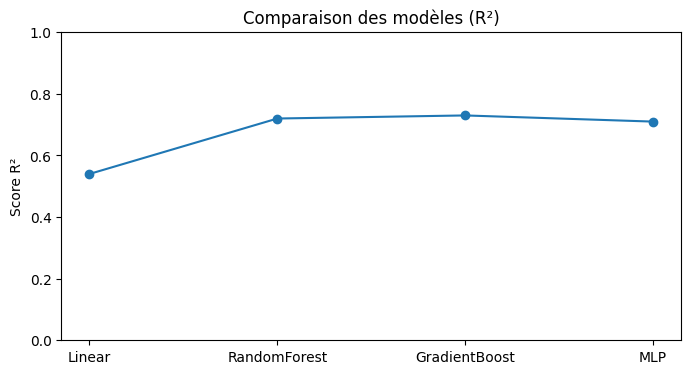

In [ ]:
models = ['Linear', 'RandomForest', 'GradientBoost', 'MLP']
r2_scores = [0.54, 0.72, 0.73, 0.71]

plt.figure(figsize=(8,4))
plt.plot(models, r2_scores, marker='o')
plt.title("Comparaison des modèles (R²)")
plt.ylabel("Score R²")
plt.ylim(0,1)
plt.show()

In [ ]:
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

print("R2 Score:", r2_score(y_test_exp, y_pred_exp))
print("RMSE:", np.sqrt(mean_squared_error(y_test_exp, y_pred_exp)))

R2 Score: 0.23591470388730607
RMSE: 16948682.172080394


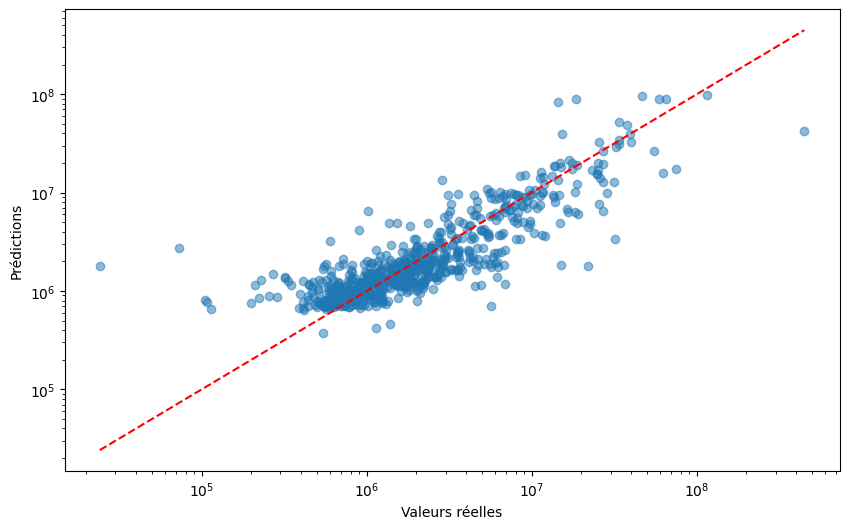

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_exp, y_pred_exp, alpha=0.5)
plt.plot([min(y_test_exp), max(y_test_exp)], [min(y_test_exp), max(y_test_exp)], linestyle='--', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Valeurs réelles')
plt.ylabel('Prédictions')
plt.show()

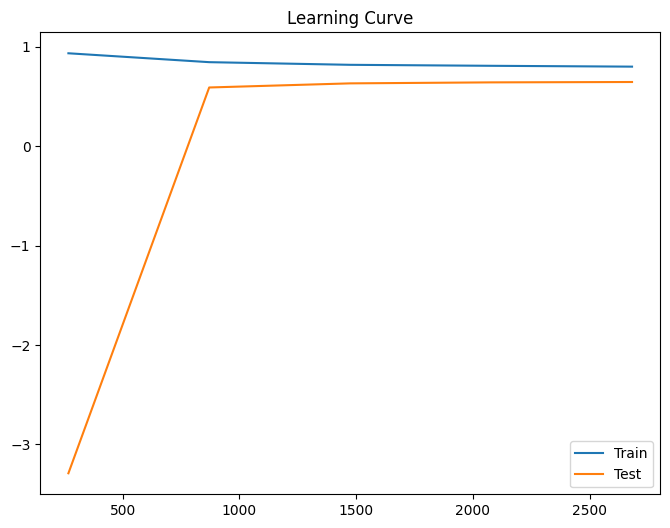

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    pipeline_gb, X, y, cv=5
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test")
plt.legend()
plt.title("Learning Curve")
plt.show()